# ClimateGuard AI v3.0 - Climate Profiling (Clustering)

This notebook covers climate zone classification using clustering algorithms.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add src to path
sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '..')))

from src.models.climate_profiling import ClimateProfiler
from src.models.model_evaluation import ClusteringEvaluator

# Ensure plots are displayed inline
%matplotlib inline

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


## 2. Load Selected Features Data

In [2]:
# Load data from feature selection step
df = pd.read_csv('../data/processed/05_selected_features.csv')
print(f"Data loaded: {df.shape}")
print(f"Columns: {len(df.columns)}")

Data loaded: (119398, 68)
Columns: 68


## 3. Prepare Features for Clustering

In [3]:
# Select numerical features for clustering
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
X = df[numerical_cols].fillna(0)

print(f"Features for clustering: {len(X.columns)}")
print(f"Samples: {len(X)}")

Features for clustering: 42
Samples: 119398


## 4. Initialize Climate Profiler

In [4]:
profiler = ClimateProfiler(X)
print("Climate profiler initialized")

Climate profiler initialized


## 5. Find Optimal Number of Clusters

In [5]:
print("Finding optimal number of clusters using K-Means...")
optimal_results = profiler.find_optimal_clusters(max_clusters=10, method='kmeans')

print(f"\nOptimal number of clusters: {optimal_results['optimal_n_clusters']}")
print(f"Maximum silhouette score: {optimal_results['max_silhouette']:.4f}")

Finding optimal number of clusters using K-Means...


INFO:src.models.climate_profiling:Data preprocessed and scaled
INFO:src.models.climate_profiling:Using 10000 samples from 119398 for faster computation
INFO:src.models.climate_profiling:Testing 2 clusters...
INFO:src.models.climate_profiling:  Silhouette score: 0.1194
INFO:src.models.climate_profiling:Testing 3 clusters...
INFO:src.models.climate_profiling:  Silhouette score: 0.1083
INFO:src.models.climate_profiling:Testing 4 clusters...
INFO:src.models.climate_profiling:  Silhouette score: 0.0945
INFO:src.models.climate_profiling:Testing 5 clusters...
INFO:src.models.climate_profiling:  Silhouette score: 0.0872
INFO:src.models.climate_profiling:Testing 6 clusters...
INFO:src.models.climate_profiling:  Silhouette score: 0.0894
INFO:src.models.climate_profiling:Testing 7 clusters...
INFO:src.models.climate_profiling:  Silhouette score: 0.1008
INFO:src.models.climate_profiling:Testing 8 clusters...
INFO:src.models.climate_profiling:  Silhouette score: 0.0969
INFO:src.models.climate_profi


Optimal number of clusters: 2
Maximum silhouette score: 0.1194


## 6. K-Means Clustering

In [6]:
# Use optimal number of clusters
n_clusters = optimal_results['optimal_n_clusters']
kmeans_labels = profiler.kmeans_clustering(n_clusters=n_clusters)

print(f"K-Means clustering completed with {n_clusters} clusters")
print(f"Cluster distribution:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

INFO:src.models.climate_profiling:K-Means clustering completed with 2 clusters


K-Means clustering completed with 2 clusters
Cluster distribution:
0    66273
1    53125
Name: count, dtype: int64


In [7]:
import pickle
import os
from sklearn.cluster import KMeans

# Save the K-Means model
model_dir = '../models'
os.makedirs(model_dir, exist_ok=True)

# Save the profiler's K-Means model
with open(f'{model_dir}/06_kmeans_clustering_model.pkl', 'wb') as f:
    # Save the K-Means model
    model_dir = '../models'
    os.makedirs(model_dir, exist_ok=True)

    kmeans_model = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans_model.fit(profiler.scaler.transform(X))

    with open(f'{model_dir}/06_kmeans_clustering_model.pkl', 'wb') as f:
        pickle.dump(kmeans_model, f)

    print(f"K-Means model saved to {model_dir}/06_kmeans_clustering_model.pkl")

    # Also save the scaler used for preprocessing
    with open(f'{model_dir}/06_clustering_scaler.pkl', 'wb') as f:
        pickle.dump(profiler.scaler, f)

    print(f"Scaler saved to {model_dir}/06_clustering_scaler.pkl")

print(f"K-Means model saved to {model_dir}/06_kmeans_clustering_model.pkl")

# Also save the scaler used for preprocessing
with open(f'{model_dir}/06_clustering_scaler.pkl', 'wb') as f:
    pickle.dump(profiler.scaler, f)

print(f"Scaler saved to {model_dir}/06_clustering_scaler.pkl")

K-Means model saved to ../models/06_kmeans_clustering_model.pkl
Scaler saved to ../models/06_clustering_scaler.pkl
K-Means model saved to ../models/06_kmeans_clustering_model.pkl
Scaler saved to ../models/06_clustering_scaler.pkl


## 7. DBSCAN Clustering  

In [8]:
dbscan_labels = profiler.dbscan_clustering(eps=0.5, min_samples=5)

print(f"DBSCAN clustering completed")
print(f"Number of clusters found: {len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)}")
print(f"Noise points: {list(dbscan_labels).count(-1)}")

INFO:src.models.climate_profiling:DBSCAN clustering completed with 3 clusters


DBSCAN clustering completed
Number of clusters found: 3
Noise points: 119382


## 8. Gaussian Mixture Clustering

In [9]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=n_clusters, random_state=42)
gmm_labels = gmm.fit_predict(X)

print(f"Gaussian Mixture clustering completed with {n_clusters} components")
print(f"Cluster distribution:")
print(pd.Series(gmm_labels).value_counts().sort_index())

Gaussian Mixture clustering completed with 2 components
Cluster distribution:
0    92862
1    26536
Name: count, dtype: int64


## 9. Agglomerative Clustering

In [10]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import KNeighborsClassifier

# Perform agglomerative clustering on a sample to avoid O(n^2) memory usage,
# then propagate labels to the full dataset via k-NN.
sample_size = min(10000, len(X))
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X), size=sample_size, replace=False)
X_sample = X.iloc[sample_idx]

agg = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
labels_sample = agg.fit_predict(X_sample)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_sample, labels_sample)
agg_labels = knn.predict(X)

print(f"Agglomerative clustering completed with {n_clusters} clusters")
print(f"Cluster distribution:")
print(pd.Series(agg_labels).value_counts().sort_index())

Agglomerative clustering completed with 2 clusters
Cluster distribution:
0    106185
1     13213
Name: count, dtype: int64


## 10. Evaluate Clustering Results

In [11]:
# Evaluate K-Means clustering
evaluator = ClusteringEvaluator(X, kmeans_labels)
cluster_report = evaluator.generate_evaluation_report()
evaluator.print_report()

CLUSTERING EVALUATION REPORT

CLUSTERING METRICS:
  Silhouette Score: 0.1569
  Davies-Bouldin Score: 2.1615
  Calinski-Harabasz Score: 16252.66



## 11. Get Cluster Characteristics 

In [12]:
cluster_stats = profiler.get_cluster_characteristics()
print("Cluster characteristics:")
display(cluster_stats)

Cluster characteristics:


latitude            longitude           temperature            \
              mean       std       mean       std        mean       std   
cluster                                                                   
-1       23.098879  5.791249  80.246725  5.763667   20.304812  6.538349   
 0       29.404000  0.405006  75.760000  0.475552   13.180000  0.432435   
 1       29.225000  0.327826  75.761667  0.537528   12.533333  0.216025   
 2       27.148000  0.179639  79.972000  0.807818   10.740000  0.089443   

         wind_mph           wind_degree              ...  dew_point            \
             mean       std        mean         std  ...       mean       std   
cluster                                              ...                        
-1       5.024312  2.825251  157.486288  115.406106  ...  11.437463  9.168635   
 0       5.480000  0.109545  338.400000    7.797435  ...  -0.977218  0.082655   
 1       7.166667  0.225093  314.000000    6.957011  ...  -3.929821  0.123820   
 2       7.740000  0.219089  284.400000    4.827007  ...   0.511976  0.266694   

        fog_indicator           low_visibility_alert            pm_ratio  \
                 mean       std                 mean       std      mean   
cluster                                                                    
-1            0.01517  0.122228             0.157159  0.363952  0.807101   
 0            0.00000  0.000000             0.000000  0.000000  0.867758   
 1            0.00000  0.000000             0.000000  0.000000  0.898194   
 2            0.00000  0.000000             0.000000  0.000000  0.938748   

                  air_quality_alert            
              std              mean       std  
cluster                                        
-1       0.121614          0.539059  0.498474  
 0       0.007336          1.000000  0.000000  
 1       0.004735          1.000000  0.000000  
 2       0.004075          1.000000  0.000000  

[4 rows x 84 columns]

## 12. Add Cluster Labels to Dataset

In [13]:
# Use K-Means labels as final clusters
df['climate_zone'] = kmeans_labels

print(f"Added climate zone labels to dataset")
print(f"Climate zone distribution:")
print(df['climate_zone'].value_counts().sort_index())

Added climate zone labels to dataset
Climate zone distribution:
climate_zone
0    66273
1    53125
Name: count, dtype: int64


## 13. Analyze Climate Zones

In [14]:
# Group by climate zone and analyze
zone_analysis = df.groupby('climate_zone')[numerical_cols].agg(['mean', 'std'])
print("Climate zone analysis:")
display(zone_analysis)

Climate zone analysis:


latitude            longitude           temperature            \
                   mean       std       mean       std        mean       std   
climate_zone                                                                   
0             25.178664  4.447484  80.565853  5.566391   17.321190  6.287718   
1             20.506030  6.211533  79.847660  5.976352   24.024408  4.671972   

              wind_mph           wind_degree              ...  dew_point  \
                  mean       std        mean         std  ...       mean   
climate_zone                                              ...              
0             4.200032  1.944587  148.495556  120.814160  ...   7.106251   
1             6.053135  3.363805  168.748800  107.241918  ...  16.836681   

                       fog_indicator           low_visibility_alert            \
                   std          mean       std                 mean       std   
climate_zone                                                                    
0             8.111977      0.010713  0.102950             0.129796  0.336082   
1             7.369987      0.020725  0.142463             0.191247  0.393287   

              pm_ratio           air_quality_alert            
                  mean       std              mean       std  
climate_zone                                                  
0             0.842175  0.083591          0.854496  0.352611  
1             0.763375  0.145175          0.145694  0.352803  

[2 rows x 84 columns]

## 14. Visualize Climate Zones

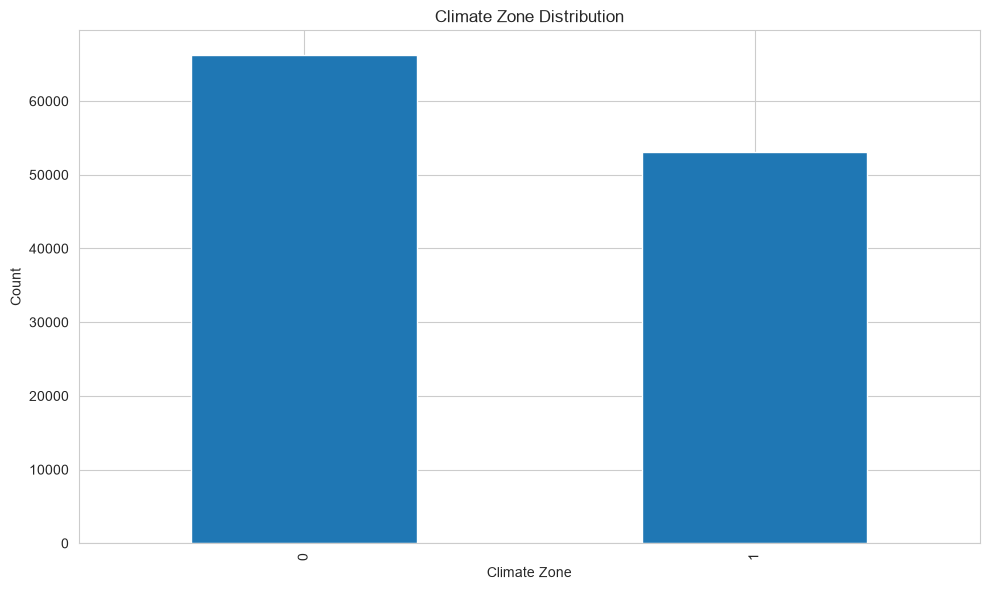

Climate zone distribution plot displayed


In [15]:
# Plot cluster distribution
plt.figure(figsize=(10, 6))
df['climate_zone'].value_counts().sort_index().plot(kind='bar')
plt.title('Climate Zone Distribution')
plt.xlabel('Climate Zone')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print("Climate zone distribution plot displayed")

## 15. Print Clustering Report

In [16]:
profiler.print_report()

CLIMATE PROFILING REPORT

OPTIMAL_CLUSTERS:

KMEANS:
  Number of clusters: 2
  Silhouette Score: 0.1214
  Davies-Bouldin Score: 2.6162
  Calinski-Harabasz Score: 15604.75

DBSCAN:
  Number of clusters: 3
  Silhouette Score: 0.8045
  Davies-Bouldin Score: 0.2445
  Calinski-Harabasz Score: 319.45
  Noise points: 119382



## 16. Save Data with Climate Zones

In [17]:
df.to_csv('../data/processed/06_climate_zones.csv', index=False)
print("\nData with climate zones saved to ../data/processed/06_climate_zones.csv")


Data with climate zones saved to ../data/processed/06_climate_zones.csv


## Summary

In this notebook, we:
1. Loaded the selected features data
2. Found optimal number of clusters using elbow method
3. Applied K-Means clustering
4. Applied DBSCAN clustering
5. Applied Gaussian Mixture clustering
6. Applied Agglomerative clustering
7. Evaluated clustering results using metrics
8. Analyzed cluster characteristics
9. Added climate zone labels to dataset
10. Visualized climate zone distribution
11. Saved data with climate zones for prediction models
12. **Saved K-Means model and scaler as .pkl files for integration with app.py**

Next: Rainfall Prediction